# Analysis of the unique extremal sphere with four punctures

There is a unique extremal sphere with four punctures and the side-pairing pattern of the associated Fuchsian triangle group is given by the permutation (1,2)(3,4)(5,10)(6,7)(8,9).

In [1]:
g=0 #Genus.
n=4 #Number of cusps.
b=0 #Number of boundary components.
m=12*g+4*n-6 #Number of sides of the fundamental domain.

half_alpha=find_root(2*sin(x)-sin(pi/4-3*x/2)==0, 0.01, pi/m)

alpha=2*half_alpha #Measure of the angles in the equilateral triangles of DeBlois decomposition.
beta=N((pi-(m-n)*half_alpha)/n) #Measure of the positive angles of the horocyclic ideal triangles of DeBlois decomposition.
radius=arccosh(1/(2*sin(half_alpha))) #Extremal radius.

#Lengths and distances in the fundamental domain:
fd_half_edge=arccosh(cos(half_alpha)/sin(pi/3))
fd_edge=2*fd_half_edge #Length of the sides of type II.

fd_distance_vertex=N(arccosh((cos(half_alpha)*cos(pi/3))/(sin(half_alpha)*sin(pi/3))))
#Distance from the origin (the center of our fundamental domain) to the proper non-right vertices of the fundamental domain.
fd_first_distance, fd_second_distance=2*radius, 2*fd_distance_vertex+fd_edge #First two admissible distances.

#Euclidean version of all the lenghts and distances:
r_euc=tanh(radius/2)
fd_edge_euc=tanh(fd_edge/2)
fd_dist_vertex_euc=tanh(fd_distance_vertex/2)
second_distance_euc=tanh(fd_second_distance/2)

In [2]:
#Vertices and edges of the fundamental domain:
PD=HyperbolicPlane().PD()

fd_vertices=[1+0*I,fd_dist_vertex_euc*(cos(beta+half_alpha)+I*sin(beta+half_alpha)),cos(2*beta+alpha)+I*sin(2*beta+alpha)]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+3*half_alpha)+I*sin(3*beta+3*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(3*beta+5*half_alpha)+I*sin(3*beta+5*half_alpha)),cos(4*beta+3*alpha)+I*sin(4*beta+3*alpha)]
fd_vertices+=[fd_dist_vertex_euc*(cos(5*beta+7*half_alpha)+I*sin(5*beta+7*half_alpha)),cos(6*beta+4*alpha)+I*sin(6*beta+4*alpha)]
fd_vertices+=[fd_dist_vertex_euc*(cos(7*beta+9*half_alpha)+I*sin(7*beta+9*half_alpha))]
fd_vertices+=[fd_dist_vertex_euc*(cos(beta+half_alpha)-I*sin(beta+half_alpha))]

fd_edges=[PD.get_geodesic(fd_vertices[k],fd_vertices[k+1]) for k in [0..m-2]]
fd_edges+=[PD.get_geodesic(fd_vertices[0],fd_vertices[-1])]

fd_midpoints=[(r_euc-0.03)*(cos(beta)-I*sin(beta)),(r_euc-0.03)*(cos(beta)+I*sin(beta))]
fd_midpoints+=[(r_euc-0.03)*(cos(beta+alpha)+I*sin(beta+alpha)),(r_euc-0.03)*(cos(3*beta+alpha)+I*sin(3*beta+alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(3*beta+2*alpha)+I*sin(3*beta+2*alpha)),(r_euc-0.03)*(cos(3*beta+3*alpha)+I*sin(3*beta+3*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(5*beta+3*alpha)+I*sin(5*beta+3*alpha)),(r_euc-0.03)*(cos(5*beta+4*alpha)+I*sin(5*beta+4*alpha))]
fd_midpoints+=[(r_euc-0.03)*(cos(7*beta+4*alpha)+I*sin(7*beta+4*alpha)),(r_euc-0.03)*(cos(7*beta+5*alpha)+I*sin(7*beta+5*alpha))]

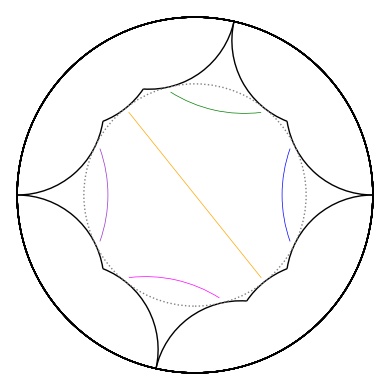

In [3]:
identifications=plot(PD.get_geodesic(fd_midpoints[0], fd_midpoints[1]), thickness=0.5)
identifications+=plot(PD.get_geodesic(fd_midpoints[2], fd_midpoints[3]), thickness=0.5, color='green')
identifications+=plot(PD.get_geodesic(fd_midpoints[4], fd_midpoints[9]), thickness=0.5, color='orange')
identifications+=plot(PD.get_geodesic(fd_midpoints[5], fd_midpoints[6]), thickness=0.5, color='darkorchid')
identifications+=plot(PD.get_geodesic(fd_midpoints[7], fd_midpoints[8]), thickness=0.5, color='magenta')

polygon=Graphics()
for edge in fd_edges:
    polygon+=plot(edge, axes=false, color='black')

fundamental_domain=polygon+identifications

fundamental_domain+circle((0,0), r_euc, color='grey', thickness=1, linestyle='dotted')

In [4]:
#The following function plots the image of the fundamental domain by an isometry.
#Inputs: g (isometry in the Poincaré disc model), col ('str'), style ('str', default='-'), w ('float', default='1')
#Outputs: It returns a figure with the image by g of the fundamental domain, where the lines have color col, linestyle style and thickness w.

def movepolygon(g, col, style='-', w=1):
    global fd_edges
    g_fd=Graphics()
    g_fd_edges=[g*edge for edge in fd_edges]
    for j in [0..m-1]:
        g_fd+=plot(g_fd_edges[j], color=col, axes=False, linestyle=style, thickness=w)
    return g_fd

In [5]:
#Definition of the side-pairing transformations:
fd_edges_approx=[PD.get_geodesic(fd_vertices[k].n(),fd_vertices[k+1].n()) for k in [0..m-2]]
fd_edges_approx+=[PD.get_geodesic(fd_vertices[m-1].n(),fd_vertices[0].n())]

simbas=PD.get_geodesic(fd_vertices[1].n(),fd_vertices[6].n()).reflection_involution()

ref_0=[]
for j in [0..len(fd_edges_approx)-1]:
    ref_0.append(fd_edges_approx[j].reflection_involution())
ref=[PD.get_isometry(refl.matrix().n()) for refl in ref_0]

rot=PD.get_isometry(matrix(2,[(e^(I*(half_alpha/2+beta/2))).n(),0,0,(e^(-I*(half_alpha/2+beta/2))).n()]))

side_pairings=[rot^(-2)*simbas*ref[0],rot^2*simbas*ref[1],rot^2*simbas*ref[2],simbas*ref[3],rot^(-2)*simbas*ref[4]]
side_pairings+=[rot^(-2)*simbas*ref[5],rot^2*simbas*ref[6],rot^2*simbas*ref[7],simbas*ref[8],rot^(-2)*simbas*ref[9]]

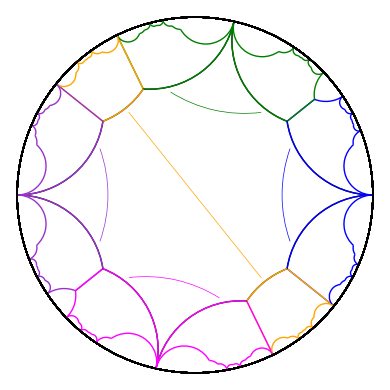

In [6]:
polygon_color=fundamental_domain
list1=[0,1,3,4,6]
col1=['blue','green','orange','darkorchid','magenta']

for j in [0..len(list1)-1]:
    polygon_color+=movepolygon(side_pairings[list1[j]], col1[j])+movepolygon(side_pairings[list1[j]]^(-1), col1[j])
polygon_color

### Functions needed for finding centers of hidden extremal discs.

In [7]:
#The following function calculates the generalized circle that passes through three fixed points a,b,c of the hyperbolic plane.
#Inputs: a,b,c (points of the Poincaré disc model), col ('str', default=0), style ('str')
#Outputs: if col!=0, ThreePointsCircle returns the plot of the generalized circle C that passes through a,b,c of color col and linestyle style,
#while if col==0 it returns only the algebraic expression of C.

def ThreePointsCircle(a,b,c,col=0,style='-'): 
    x,y=var('x'), var('y')
    u,v,w=var('u'),var('v'),var('w')
    
    if a in PD:
        a_1=N(a.coordinates())
    else:
        a_1=N(a)
    if b in PD:
        b_1=N(b.coordinates())
    else:
        b_1=N(b)
    if c in PD:
        c_1=N(c.coordinates())
    else:
        c_1=N(c)
        
    if abs((a_1-b_1)*(b_1-c_1)*(c_1-a_1))<10^(-5): return 'The three points introduced are not all different.'
    else:
        if abs(((c_1-a_1)/(b_1-a_1)).imag())<10^(-5): 
            if abs((b_1).real()-(a_1).real())>10^(-5):
                circle=(y-u*x-v==0)
                coc=(a_1.imag()-b_1.imag())/(a_1.real()-b_1.real())
                eq=circle.subs(u=coc).subs(v=a_1.imag()-a_1.real()*coc)
            else:
                eq=(x-a_1.real()==0)
        else:
            circle=((x-u)^2+(y-v)^2-w^2==0)
            eq1=circle.subs(x==a_1.real()).subs(y==a_1.imag())
            eq2=circle.subs(x==b_1.real()).subs(y==b_1.imag())
            eq3=circle.subs(x==c_1.real()).subs(y==c_1.imag())
            coef=solve([eq1,eq2,eq3],u,v,w)
            control=min(abs(N(coef[1][0].rhs())),abs(N(coef[1][1].rhs())),abs(N(coef[1][2].rhs())))
            if control>10^10: circle=((u/v)*x+y+(u^2+v^2-w^2)/(-2*v)==0)
            eq=circle.subs(u=N(coef[1][0].rhs())).subs(v=N(coef[1][1].rhs())).subs(w=N(coef[1][2].rhs()))
        
        if col==0: return eq
        else:
            return implicit_plot(eq, (x,-1,1), (y,-1,1), color=col, axes=false, linestyle=style, linewidth=0.5)

In [8]:
#The following function calculates the set of points of the hyperbolic plane that move a fixed distance under the action of a hyperbolic isometry or a glide-reflection.
#Inputs: s (hyperbolic isometry or glide-reflection), d ('float'), c ('str', default=0)
#Outputs: if c!=0, banana returns the plot of the bananas of the isometry s associated to the distance d in color c, while if c==0 it returns the algebraic expression of the bananas.

def banana(s,d,c=0):
    origin=PD.get_point(0+0*I)
    T=N((s*s).translation_length()/2)
    
    if bool(abs(T-d)<10^(-5)):
        if bool(c==0)==false:
            return plot(s.axis(), color=c)
        else:
            return s.axis()
        
    if bool(s.classification()=='hyperbolic'):
        dist_banana_axis=N(arccosh(sinh(d/2)/sinh(T/2)))
    elif bool(s.classification()=='orientation-reversing hyperbolic'):
        dist_banana_axis=N(arccosh(cosh(d/2)/cosh(T/2)))
        
    initial,final=N((s*s).axis().ideal_endpoints()[0].coordinates()),N((s*s).axis().ideal_endpoints()[1].coordinates())
    middle=(initial+final)/2
    if abs(middle)<10^(-5):
        border_1, border_2= cos(arg(initial)+pi/2)+I*sin(arg(initial)+pi/2), cos(arg(initial)+3*pi/2)+I*sin(arg(initial)+3*pi/2)
    else:
        border_1=cos(arg(middle))+I*sin(arg(middle))
        border_2=-border_1

    dist_origin_axis=(s*s).axis().dist(origin)
    
    if bool(d>T) or bool(abs(d-T)<10^(-5)):
        mod_1=tanh(abs(dist_origin_axis-dist_banana_axis)/2)
        mod_2=tanh((dist_origin_axis+dist_banana_axis)/2)
        argu=arg(border_1)
        if bool(dist_banana_axis<dist_origin_axis) or bool(abs(dist_banana_axis-dist_origin_axis)<10^(-5)):
            part_1=ThreePointsCircle(initial,final,mod_1*(cos(argu)+I*sin(argu)), c)
            part_2=ThreePointsCircle(initial,final,mod_2*(cos(argu)+I*sin(argu)), c)
        else:
            part_1=ThreePointsCircle(initial,final,mod_1*(cos(argu+pi)+I*sin(argu+pi)), c, '-')
            part_2=ThreePointsCircle(initial,final,mod_2*(cos(argu)+I*sin(argu)), c, ':')
        if bool(c==0)==false:
            return part_1+part_2
        else:
            return [part_1,part_2]
    else:
        return 'ERROR'

In [9]:
#The following function calculates the set of points of the hyperbolic plane that move a fixed distance under the action of a parabolic isometry.
#Inputs: theta ('float'), distances (list of lists [[a_1,...], [a_2,...],...,[a_n,...]] with ai an unsigned float), m ('int'), c ('str', default=0)
#Outputs: if c!=0, bananapar returns the plot of the banana of a parabolic isometry fixing the ideal point exp(I*theta) and associated to the distance distances[m][0] in color c,
#while if c==0 it returns only the algebraic expression of the banana.

def bananapar(theta,distances,m,c=0):
    var('x y')
    a=cos(theta)
    b=sin(theta)
    d=sinh(distances[0][0]/2)/sinh(distances[m][0]/2)
    
    #Poisson kernel: P(z,w)=(1-|z|^2)/|z-w|^2=Re(f(z)) with f(z)=(w+z)/(w-z).
    z1=(d*a+sqrt(1-b^2*d^2))/(d+1)
    z2=(d*a-sqrt(1-b^2*d^2))/(d+1)
    
    if abs(theta)>10^(-5) and abs(theta-pi)>10^(-5):
        lambda1=(z1^2-1)/(2*(z1*a-1))
        lambda2=(z2^2-1)/(2*(z2*a-1))
    elif abs(theta-pi)<=10^(-5):
        lambda1=(1-z1)/2
        lambda2=(1-z2)/2
    else:
        lambda1=(z1+1)/2
        lambda2=(z2+1)/2

    eq1=(x-lambda1*a)^2+(y-lambda1*b)^2-(1-lambda1)^2
    eq2=(x-lambda2*a)^2+(y-lambda2*b)^2-(1-lambda2)^2
    if c==0: return (eq1,eq2)
    else: return implicit_plot(eq1==0, (x, -1, 1), (y, -1, 1), color=c, linestyle='--', linewidth=0.5)+implicit_plot(eq2==0, (x, -1, 1), (y, -1, 1), color=c,linewidth=0.5)

In [10]:
#The following function returns the intersection points of two generalized circles in the hyperbolic plane.
#Inputs: pol1,pol2 ('symbolic expressions')
#Outputs: list of points in the hyperbolic plane in which the generalized circles pol1==0 and pol2==0 intersect.

def coord_intersection(pol1,pol2):
    x,y=var('x'), var('y')
    R=PolynomialRing(RR,['x','y'])
    gr1,gr2=2,2
    if R(pol1).coefficient({x:0,y:2})==0 and R(pol1).coefficient({x:2,y:0})==0:
        gr1=1
    if R(pol2).coefficient({x:0,y:2})==0 and R(pol2).coefficient({x:2,y:0})==0:
        gr1=1
    
    if gr1==1 and gr2==1:
        sol=solve([pol1,pol2],x,y)
        solution=[N(sol[0][0].rhs())+N(sol[0][1].rhs())*I]
        return [z for z in solution if abs(z)<=1]
    
    elif gr1==2 and gr2==2:
        sol=solve([pol1,pol1-pol2],x,y)
        if all([imag(sol[t][0].rhs())==0 and imag(sol[t][1].rhs())==0 for t in [0..len(sol)-1]]):
            solution=[N(sol[t][0].rhs())+N(sol[t][1].rhs())*I for t in [0..len(sol)-1]]
            return [z for z in solution if abs(z)<=1]
        else: return []
        
    else:
        sol=solve([pol1,pol2],x,y)
        if all([imag(sol[t][0].rhs())==0 and imag(sol[t][1].rhs())==0 for t in [0..len(sol)-1]]):
            solution=[N(sol[t][0].rhs())+N(sol[t][1].rhs())*I for t in [0..len(sol)-1]]
            return [z for z in solution if abs(z)<=1]
        else: return []

In [11]:
#The following function returns the elliptic isometry of order 2 in the hyperbolic plane that relates two given points.
#Inputs: p,q (points in the Poincaré disc model)
#Outputs: Elliptic isometry of order two that sends p to q and viceversa.

def rotationpi(p,q):
    p1=PD.get_point(p)
    q1=PD.get_point(q)
    geod=PD.get_geodesic(p1,q1)
    mid_point=geod.midpoint().coordinates()
    
    rot_matrix=matrix([[I, mid_point*(-I)], [mid_point.conjugate()*I, -I]])
    rotation=PD.get_isometry(rot_matrix)
    
    can_matrix=matrix([[I, 0], [0, -I]])
    can_rotation=PD.get_isometry(can_matrix)
    rotationpi=rotation*can_rotation*rotation^(-1)
    return rotationpi

In [12]:
#The following function find out if an isometry conjugates another isometry in an element of a fixed list of isometries.
#Inputs: generators (list of isometries of the hyperbolic plane), isometries (list of isometries of the hyperbolic plane), aut (isometry of the hyperbolic plane), k ('int')
#Outputs: A message about if g=aut*generators[k]*aut^(-1) equals some element in isometries or it is impossible to occur because metric conditions (it does not respect the tessellation defined by generators).
#In any of the previous cases, it returns the isometry h that give us the information and plot the image of the fundamental domain by h^(-1)*g.

def check_conj(generators,isometries,aut,k):
    conj=aut*generators[k]*aut^(-1)
    k=0
    test=0
    
    while k<len(isometries) and test==0:
        dist=origin.dist(isometries[k]^(-1)*conj*origin)
        if dist<radius:
            test=1
        k+=1
    
    if test==0: print("We have arrived to the end of the list without finding any element that confirms or denies anything.")
    else:
        print("The right element corresponds to the position ", k-1)
        print("The isometry is given by: ", isometries[k-1])
        if dist<10^(-6) and PD(1/2).dist((isometries[k-1]^(-1)*conj)*PD(1/2))<10^(-6) and (isometries[k-1]^(-1)*conj).preserves_orientation()==True:
            print("It conjugates well.")
        show(polygon+movepolygon((isometries[k-1]^(-1)*conj), 'skyblue'))

### Search of the preimages of extremal disc centers using the "bananas' method".

In [13]:
#Construction of a short list of admissible distances:
lst_index=[[j] for j in [0..m-1]]
origin=PD(0+0*I)
ln=2

for i in range(ln):
    lst_index_aux=copy(lst_index)
    for lst in lst_index_aux:
        for j in [0..m-1]:
            lst_index+=[lst+[j]]

distances_list=[]
pnts=[origin]
simbas=PD.get_geodesic(1,-1).reflection_involution()

for lst in lst_index: #Construction of isometries given as the product of at most three side-pairings of the fundamental domain.
    g=simbas*simbas^(-1)
    for j in [0..len(lst)-1]: g*=side_pairings[lst[j]]
    pt=g*origin
    distances_list+=[(origin.dist(pt), lst, g , g.classification())]
    pnts+=[pt]

In [14]:
#Refinement of the distances in distances_list, taking out the elements that repeat previous admissible distances:
distances_list.sort()
distances_list_ref=[]
k=0

while distances_list[k][0]==0: k+=1

distances_list_ref+=[distances_list[k]]

for j in [k..len(distances_list)-2]:
    if abs(distances_list[j+1][0]-distances_list[j][0])>10^(-5):
        distances_list_ref+=[distances_list[j+1]]
len(distances_list_ref)

52

In [15]:
#The first two distances of distances_list_ref coincide with the first two admissible distances we know theoretically.
abs(distances_list_ref[0][0]-fd_first_distance), N(abs(distances_list_ref[1][0]-fd_second_distance))

(2.53130849614536e-14, 3.33066907387547e-16)

In [16]:
#Refinement of the isometries in distances_list, taking out the elements that repeat previous isometries:
list_by_distances=[[] for j in [0..len(distances_list_ref)-1]] #We group isometries by their associated admissible distances.
l=0
d=distances_list_ref[0][0]

for j in [k..len(distances_list)-1]:
    if abs(distances_list[j][0]-d)<10^(-3): list_by_distances[l]+=[distances_list[j]]
    else:
        list_by_distances[l+1]+=[distances_list[j]]
        l+=1
        d=distances_list_ref[l][0]
        
isometries_t=[]
for k in [0..len(list_by_distances)-1]:
    isometries=[]
    for j in [0..len(list_by_distances[k])-1]:
        test=0
        s=0
        isometry=list_by_distances[k][j][2]
        while test==0 and s<len(isometries):
            a=(isometry*PD(0)).coordinates()-(isometries[s]*PD(0)).coordinates()
            b=(isometry*PD(1/2)).coordinates()-(isometries[s]*PD(1/2)).coordinates()
            c=(isometry*PD(-1/2)).coordinates()-(isometries[s]*PD(-1/2)).coordinates()
            if abs(a)<10^(-5) and abs(b)<10^(-5) and abs(c)<10^(-5) and (isometry*isometries[s]).preserves_orientation()==True:
                test=1 #isometry*isometries[s]==Id.
            s+=1
        if test==0: 
            isometries+=[isometry]
    isometries_t+=isometries

Once we have computed a reasonable amount of admissible distances of this extremal disc configuration, we are going to plot the a set of bananas needed to cover the whole fundamental domain with the closure of the regions they bound.

/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/plot/contour_plot.py:208: UserWarning: No contour levels were found within the data range.
  linewidths=linewidths, linestyles=linestyles)


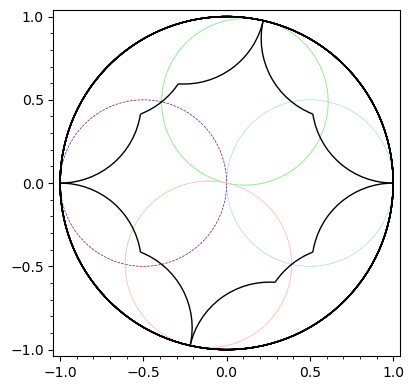

In [17]:
polygon_bananas=polygon

polygon_bananas+=bananapar(0,distances_list_ref,0,'lightblue')
polygon_bananas+=bananapar(2*beta+alpha,distances_list_ref,0,'lightgreen')
polygon_bananas+=bananapar(pi,distances_list_ref,0,'purple')
polygon_bananas+=bananapar(6*beta+4*alpha,distances_list_ref,0,'pink')

polygon_bananas.show(ymax=1, ymin=-1)

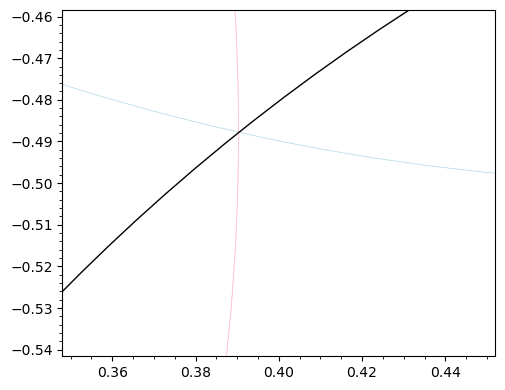

In [18]:
polygon_bananas.show(xmin=0.35,xmax=0.45,ymin=-0.54,ymax=-0.46)

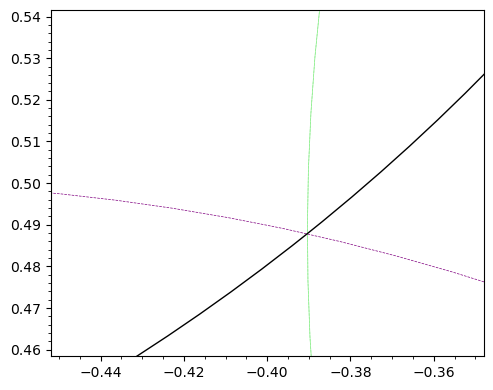

In [19]:
polygon_bananas.show(xmax=-0.35,xmin=-0.45,ymax=0.54,ymin=0.46)

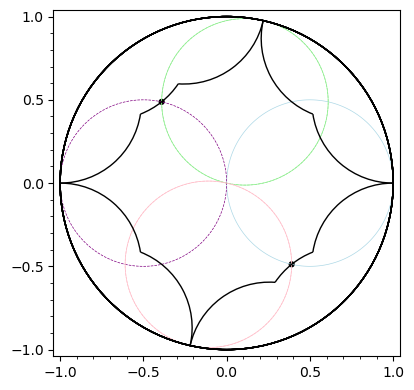

In [20]:
p1=fd_edges[3].midpoint().coordinates()
p2=fd_edges[8].midpoint().coordinates()

polygon_bananas+points([p1,p2], color='black', size='20')

As fd_first_distance is the smallest admissible distance, we do not have to calculate more bananas: as the closure of the regions bounded by the bananas represented in the previous figure cover all the fundamental domain, we do not have to take more bananas because in the open horoball bounded by each parabolic banana there cannot be any preimage of an extremal disc center, as there are no admissible bananas of the corresponding transformation passing through it.

In particular, the preimages of the extremal disc centers must be on the bananas illustrated in the previous figure. In fact, if we consider the open horoballs described previously and we take their union, we will be covering all the points of the fundamental domain except three, the origin (which we know is the preimage of an extremal disc centre by construction) and the middle points of both compact sides of the polygon. Therefore, we only need to analyse the situation of this pair of special points, which are the only other candidates to be the preimage of an extremal disc center. Observe that these points are identified by an element in the uniformizing group.

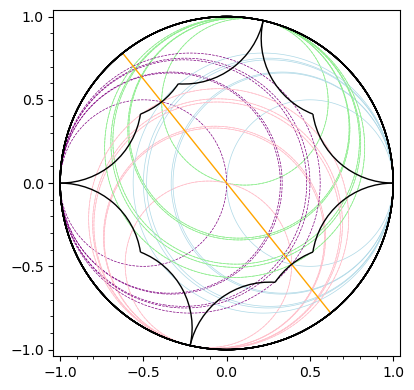

In [21]:
polygon_bananas2=polygon_bananas

polygon_bananas2+=banana(side_pairings[3], 2*radius, 'orange')

for k in [1..5]:
    polygon_bananas2+=bananapar(0,distances_list_ref,k,'lightblue')
    polygon_bananas2+=bananapar(2*beta+alpha,distances_list_ref,k,'lightgreen')
    polygon_bananas2+=bananapar(pi,distances_list_ref,k,'purple')
    polygon_bananas2+=bananapar(6*beta+4*alpha,distances_list_ref,k,'pink')

polygon_bananas2.show(ymin=-1,ymax=1)

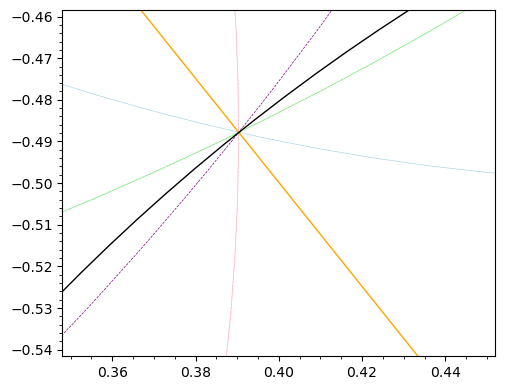

In [22]:
polygon_bananas2.show(xmin=0.35,xmax=0.45,ymin=-0.54,ymax=-0.46) #We have a candidate!

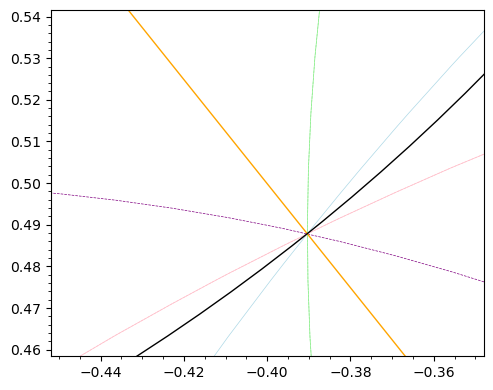

In [23]:
polygon_bananas2.show(xmax=-0.35,xmin=-0.45,ymax=0.54,ymin=0.46)
#We have another candidate! (It is identified with the previous one by an element in the uniformizing group)

There are bananas of all the colors intersecting in the two unique possible candidates (distinct to the origin) for being the preimage of an extremal disc center in the fundamental domain. As they are identified by an element in the uniformizing group, we only have to study the situation at one of these points.

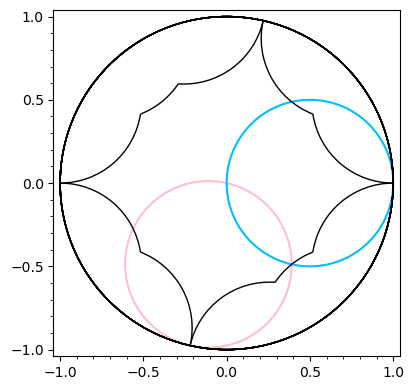

In [24]:
banana1=bananapar(6*beta+4*alpha,distances_list_ref,0)[0]==0
banana2=bananapar(0,distances_list_ref,0)[1]==0

implicit_plot(banana1,(x, -1, 1),(y, -1, 1),color='pink')+implicit_plot(banana2,(x, -1, 1),(y, -1, 1),color='deepskyblue')+polygon

In [25]:
coord_intersection(banana1,banana2)

[-5.55111512312578e-17*I, 0.390388203202208 - 0.487837323298207*I]

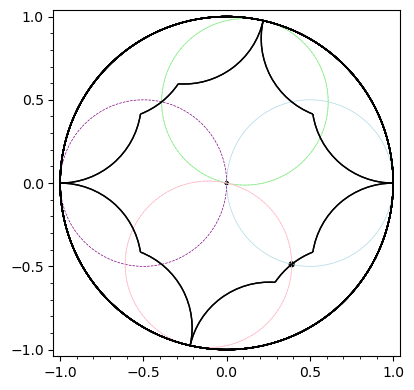

In [26]:
intersection_p=coord_intersection(banana1,banana2)[1]
bananas_point=polygon+polygon_bananas+points([intersection_p],color='black', size='20')+points([0+0*I],color='black')
bananas_point.show(ymin=-1,ymax=1)

In [27]:
#Check if the rotation of angle pi around the origin defines an automorphism of the surface.
rot=rotationpi(0+0*I, intersection_p)
geod=PD.get_geodesic(origin, PD.get_point(intersection_p))
fixed_p=geod.midpoint().coordinates()

intersection_p, fixed_p

(0.390388203202208 - 0.487837323298207*I,
 0.21922359359558516 - 0.27394642109123885*I)

Checking if rot conjugates properly the side-pairing transformation number  0
The right element corresponds to the position  0
The isometry is given by:  Isometry in PD
[ 0.999999999999997 + 2.04986365790778*I -2.00000000000000 + 0.449378477467530*I]
[-2.00000000000000 - 0.449378477467530*I  0.999999999999997 - 2.04986365790778*I]
It conjugates well.


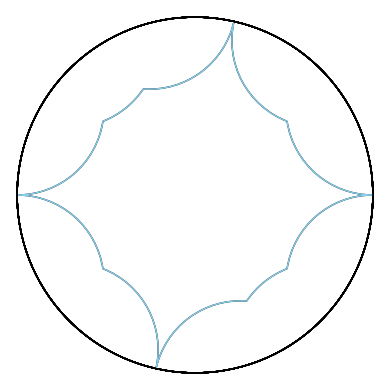

Checking if rot conjugates properly the side-pairing transformation number  1
The right element corresponds to the position  59
The isometry is given by:  Isometry in PD
[1.00000000000001 - 7.30069767669607*I 6.56155281280887 + 3.20097036088050*I]
[6.56155281280887 - 3.20097036088050*I 1.00000000000001 + 7.30069767669607*I]
It conjugates well.


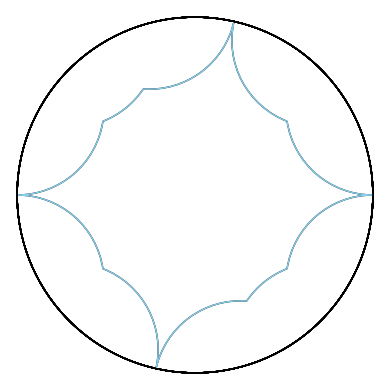

Checking if rot conjugates properly the side-pairing transformation number  2
The right element corresponds to the position  57
The isometry is given by:  Isometry in PD
[-0.999999999999994 - 7.30069767669610*I   6.56155281280889 + 3.20097036088053*I]
[  6.56155281280889 - 3.20097036088053*I -0.999999999999994 + 7.30069767669610*I]
It conjugates well.


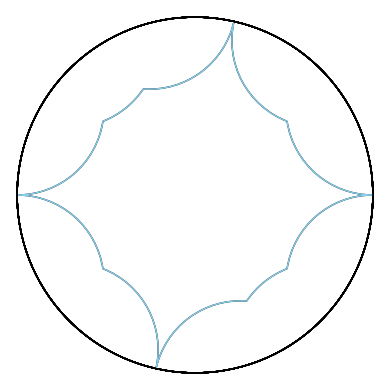

Checking if rot conjugates properly the side-pairing transformation number  3
The right element corresponds to the position  9
The isometry is given by:  Isometry in PD
[-2.28077640640442 - 4.21884749357559e-15*I      1.28077640640441 - 1.60048518044024*I]
[     1.28077640640441 + 1.60048518044024*I -2.28077640640442 + 4.21884749357559e-15*I]
It conjugates well.


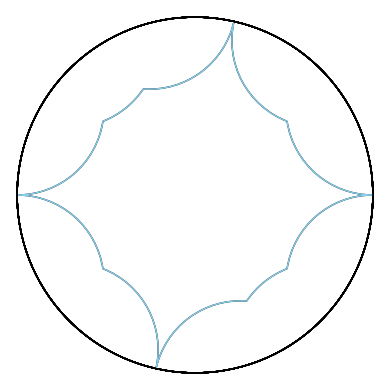

Checking if rot conjugates properly the side-pairing transformation number  4
The right element corresponds to the position  55
The isometry is given by:  Isometry in PD
[-1.00000000000004 + 7.30069767669612*I -4.56155281280891 - 5.70021249625585*I]
[-4.56155281280891 + 5.70021249625585*I -1.00000000000004 - 7.30069767669612*I]
It conjugates well.


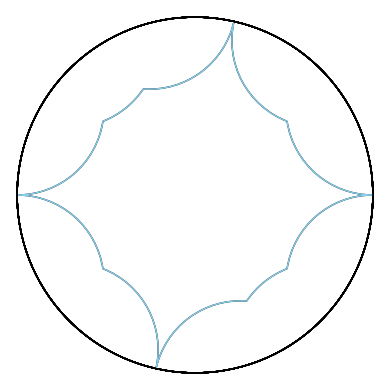

Checking if rot conjugates properly the side-pairing transformation number  5
The right element corresponds to the position  52
The isometry is given by:  Isometry in PD
[ 1.00000000000001 + 7.30069767669607*I -4.56155281280885 - 5.70021249625582*I]
[-4.56155281280885 + 5.70021249625582*I  1.00000000000001 - 7.30069767669607*I]
It conjugates well.


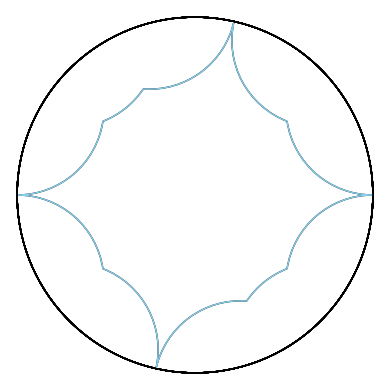

Checking if rot conjugates properly the side-pairing transformation number  6
The right element corresponds to the position  7
The isometry is given by:  Isometry in PD
[    1.00000000000001 - 2.04986365790777*I 8.43769498715119e-15 + 2.04986365790777*I]
[8.43769498715119e-15 - 2.04986365790777*I     1.00000000000001 + 2.04986365790777*I]
It conjugates well.


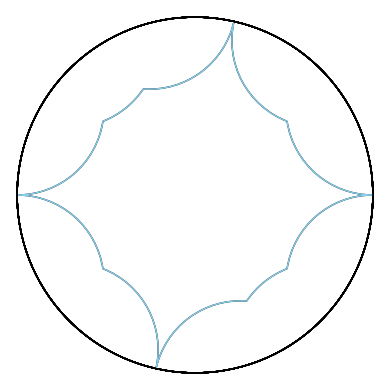

Checking if rot conjugates properly the side-pairing transformation number  7
The right element corresponds to the position  1
The isometry is given by:  Isometry in PD
[    0.999999999999977 + 2.04986365790778*I -1.95399252334028e-14 - 2.04986365790777*I]
[-1.95399252334028e-14 + 2.04986365790777*I     0.999999999999977 - 2.04986365790778*I]
It conjugates well.


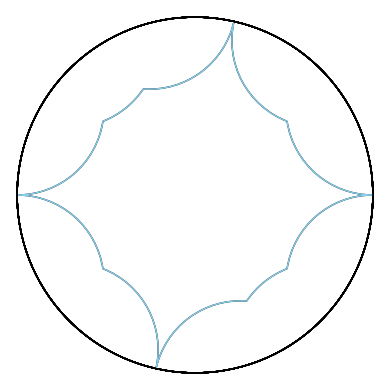

Checking if rot conjugates properly the side-pairing transformation number  8
The right element corresponds to the position  8
The isometry is given by:  Isometry in PD
[2.28077640640441 + 1.77635683940025e-14*I     1.28077640640443 - 1.60048518044023*I]
[    1.28077640640443 + 1.60048518044023*I 2.28077640640441 - 1.77635683940025e-14*I]
It conjugates well.


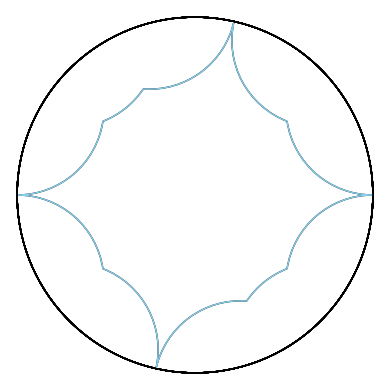

Checking if rot conjugates properly the side-pairing transformation number  9
The right element corresponds to the position  6
The isometry is given by:  Isometry in PD
[ 1.00000000000000 - 2.04986365790777*I 2.00000000000000 - 0.449378477467534*I]
[2.00000000000000 + 0.449378477467534*I  1.00000000000000 + 2.04986365790777*I]
It conjugates well.


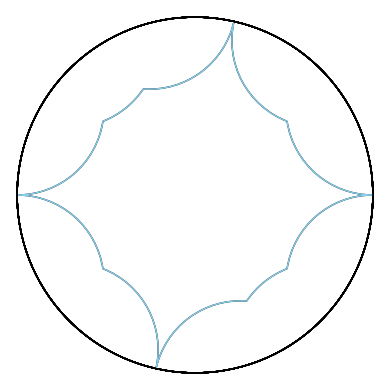

In [28]:
candidate_aut=rot
for j in [0..m-1]:
    print('Checking if rot conjugates properly the side-pairing transformation number ', j)
    check_conj(side_pairings,isometries_t,candidate_aut,j)

In the ten previous cases, the algorithm of check_conj converges and mustbeidentity is an isometry that fixes at least two points and preserves the orientation, so mustbeidentity==Id. Therefore, candidate_aut belongs to the normalizer of the uniformizating group and it defines an automorphism of the surface.

Moreover, the image of the projection of the origin by this automorphism is also an extremal disc center and intersection_p is a preimage of this point. As the origin and intersection_p (and their identified ones) were the only candidates to be the preimage of an extremal disc center in the fundamental domain, the unique forth-punctured extremal sphere has exactly two extremal discs, centered at the projections of the origin and intersection_p.

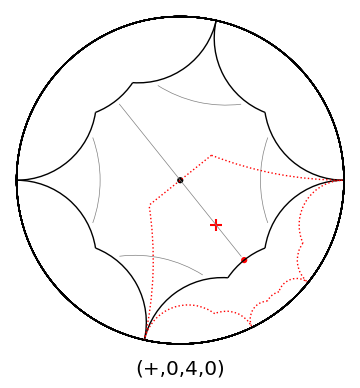

In [29]:
identifications_g=plot(PD.get_geodesic(fd_midpoints[0], fd_midpoints[1]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[2], fd_midpoints[3]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[4], fd_midpoints[9]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[5], fd_midpoints[6]), thickness=0.5, color='gray')
identifications_g+=plot(PD.get_geodesic(fd_midpoints[7], fd_midpoints[8]), thickness=0.5, color='gray')

polygon_art=polygon+identifications_g+points([0+0*I], color='black', size=20)+points([fixed_p], marker='+', size=70, color='red')
polygon_art+=points([intersection_p], color='red',size=20)+ text('(+,0,4,0)', (0,-1.15), fontsize='x-large', color='black')
polygon_art+=movepolygon(candidate_aut,'red',':')
polygon_art